# Pregunta 2
## Existe una relacion entre la desigualdad socioeconomica y el rendimiento escolar?

**Avance del proyecto 2026-1 hasta la semana 3**

Este notebook deja documentado el avance correspondiente a:

- Semana 1: inicio del proyecto.
- Semana 2: analisis exploratorio inicial.
- Semana 3: profundizacion del contexto.

**Advertencia metodologica.** Los archivos disponibles en esta carpeta no contienen puntajes academicos SIMCE ni notas escolares. El resultado educativo disponible corresponde a los **IDPS** (Indicadores de Desarrollo Personal y Social), por lo que este avance responde la pregunta de forma **exploratoria** usando esos puntajes como aproximacion al desempeno escolar. Si mas adelante quieren responder la pregunta en sentido estrictamente academico, conviene complementar con SIMCE o con otra medida de logro escolar.

### Ruta de trabajo usada en este avance

1. Unir la base reducida de CASEN con la base territorial de comuna y provincia.
2. Construir indicadores comunales de desigualdad e ingreso.
3. Agregar los puntajes IDPS por comuna para 4to basico y II medio.
4. Comparar patrones iniciales y dejar definidas las preguntas preliminares para las siguientes semanas.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 110

BASE = Path('.')


In [2]:
idps_2m = pd.read_csv(BASE / 'idps2m2022_rbd_dim_final.csv', sep=';', encoding='latin1')
idps_4b = pd.read_csv(BASE / 'idps4b2022_rbd_dim_final.csv', sep=';', encoding='latin1')
casen_reducido = pd.read_excel(BASE / 'casen_reducido.xlsx')
casen_territorio_raw = pd.read_stata(BASE / 'Base de datos provincia y comuna Casen 2022 STATA.dta', convert_categoricals=False)
casen_territorio_lbl = pd.read_stata(BASE / 'Base de datos provincia y comuna Casen 2022 STATA.dta')
idps_glosa = pd.ExcelFile(next(BASE.glob('idps2m*glosa*.xlsx')))


## Semana 1. Inicio del proyecto

### Pregunta de trabajo

La pregunta general del grupo es:

> **Existe una relacion entre la desigualdad socioeconomica y el rendimiento escolar?**

### Justificacion inicial

Esta pregunta es relevante porque combina dos dimensiones centrales del contexto chileno:

- la desigualdad socioeconomica entre territorios y hogares,
- y los resultados escolares observables en establecimientos educacionales.

### Decision metodologica inicial

Con los archivos efectivamente disponibles en la carpeta, la estrategia mas razonable para el avance inicial es trabajar a **nivel comunal**:

- **CASEN 2022** entrega variables socioeconomicas de personas y hogares.
- La base territorial permite recuperar la **comuna** de cada observacion CASEN.
- **IDPS 2022** entrega puntajes por establecimiento, junto con el codigo de comuna del establecimiento.

Por eso, en esta primera etapa la unidad de analisis se fija en la **comuna**, para poder cruzar ambas fuentes.

### Hipotesis preliminar

Una hipotesis intuitiva es que las comunas con mayor desigualdad o mayor pobreza podrian tender a mostrar peores resultados escolares. Sin embargo, este avance asume desde el principio que la relacion puede no ser lineal y que pueden influir otros factores, por ejemplo ruralidad, tipo de establecimiento o composicion socioeconomica de las escuelas.

In [3]:
resumen_fuentes = pd.DataFrame([
    {
        'dataset': 'casen_reducido.xlsx',
        'unidad_observacion': 'persona',
        'filas': len(casen_reducido),
        'columnas': casen_reducido.shape[1],
        'aporte_al_analisis': 'Variables socioeconomicas: ingreso, pobreza, escolaridad y hacinamiento.'
    },
    {
        'dataset': 'Base de datos provincia y comuna Casen 2022 STATA.dta',
        'unidad_observacion': 'persona',
        'filas': len(casen_territorio_raw),
        'columnas': casen_territorio_raw.shape[1],
        'aporte_al_analisis': 'Permite recuperar codigo de comuna y factor de expansion comunal.'
    },
    {
        'dataset': 'idps2m2022_rbd_dim_final.csv',
        'unidad_observacion': 'establecimiento x dimension',
        'filas': len(idps_2m),
        'columnas': idps_2m.shape[1],
        'aporte_al_analisis': 'Puntajes IDPS para II medio.'
    },
    {
        'dataset': 'idps4b2022_rbd_dim_final.csv',
        'unidad_observacion': 'establecimiento x dimension',
        'filas': len(idps_4b),
        'columnas': idps_4b.shape[1],
        'aporte_al_analisis': 'Puntajes IDPS para 4to basico.'
    }
])

resumen_fuentes

,dataset,unidad_observacion,filas,columnas,aporte_al_analisis
0,casen_reducido.xlsx,persona,202231,15,"Variables socioeconomicas: ingreso, pobreza, e..."
1,Base de datos provincia y comuna Casen 2022 ST...,persona,202231,6,Permite recuperar codigo de comuna y factor de...
2,idps2m2022_rbd_dim_final.csv,establecimiento x dimension,32736,19,Puntajes IDPS para II medio.
3,idps4b2022_rbd_dim_final.csv,establecimiento x dimension,78815,19,Puntajes IDPS para 4to basico.


## Semana 2. Analisis exploratorio inicial

### Importacion y limpieza preliminar

En esta etapa se corrigieron dos problemas del notebook original:

- apuntaba a un archivo `casen_2022.dta` que no estaba dentro de la carpeta,
- y no hacia el cruce territorial necesario entre CASEN e IDPS.

La limpieza que se deja implementada a continuacion hace tres cosas:

1. une la base reducida de CASEN con la base territorial usando `folio` e `id_persona`,
2. conserva el **codigo de comuna** para el cruce con educacion,
3. genera indicadores comunales de ingreso, desigualdad y pobreza con ponderacion comunal (`expc`).

In [4]:
MAP_DEPENDENCIA = {
    1: 'Municipal',
    2: 'Particular subvencionado',
    3: 'Particular pagado',
    4: 'SLEP'
}

MAP_GSE = {
    1: 'Bajo',
    2: 'Medio bajo',
    3: 'Medio',
    4: 'Medio alto',
    5: 'Alto'
}

MAP_RURAL = {
    1: 'Urbano',
    2: 'Rural'
}

MAP_INDICADOR = {
    'AM': 'Autoestima academica y motivacion escolar',
    'CC': 'Clima de convivencia escolar',
    'HV': 'Habitos de vida saludable',
    'PF': 'Participacion y formacion ciudadana'
}

MAP_DIMENSION = {
    'AA': 'Autopercepcion y autovaloracion academica',
    'AC': 'Habitos de autocuidado',
    'AO': 'Ambiente organizado',
    'AR': 'Ambiente de respeto',
    'AS': 'Ambiente seguro',
    'HA': 'Habitos alimentarios',
    'ME': 'Motivacion escolar',
    'PA': 'Participacion',
    'SP': 'Sentido de pertenencia',
    'VA': 'Habitos de vida activa',
    'VD': 'Vida democratica'
}


def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])


def weighted_gini(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
    x = x[mask]
    w = w[mask]
    if len(x) == 0:
        return np.nan
    order = np.argsort(x)
    x = x[order]
    w = w[order]
    cumw = np.cumsum(w)
    cumxw = np.cumsum(x * w)
    if cumxw[-1] == 0:
        return 0.0
    return 1 - 2 * np.sum(w * (cumxw - (x * w / 2))) / (cumw[-1] * cumxw[-1])


casen_territorial = casen_reducido.merge(
    casen_territorio_raw[['folio', 'id_persona', 'provincia', 'comuna', 'expc']],
    on=['folio', 'id_persona'],
    how='left'
)
casen_territorial['provincia_nombre'] = casen_territorio_lbl['provincia'].astype(str)
casen_territorial['comuna_nombre'] = casen_territorio_lbl['comuna'].astype(str)
casen_territorial = casen_territorial.rename(columns={'comuna': 'cod_comuna'})

for df in [idps_2m, idps_4b]:
    df['dependencia'] = df['cod_depe2'].map(MAP_DEPENDENCIA)
    df['gse'] = df['cod_grupo'].map(MAP_GSE)
    df['ruralidad'] = df['cod_rural_rbd'].map(MAP_RURAL)
    df['indicador'] = df['ind'].map(MAP_INDICADOR)
    df['dimension'] = df['dim'].map(MAP_DIMENSION)

casen_territorial.head()

,folio,id_persona,region,region_geo,area,nse,ypchtotcor,qaut,dau,pobreza,pobreza_multi,esc,agnoesc,ind_hacina,expr,provincia,cod_comuna,expc,provincia_nombre,comuna_nombre
0,100090101,1,16,10,2,4,"336,965.00",2.00,3.00,3.00,0.00,1.00,1.00,1,43,163,16303,52,Punilla,Ñiquén
1,100090101,2,16,10,2,4,"336,965.00",2.00,3.00,3.00,0.00,4.00,4.00,1,43,163,16303,53,Punilla,Ñiquén
2,100090101,3,16,10,2,4,"336,965.00",2.00,3.00,3.00,0.00,15.00,15.00,1,44,163,16303,52,Punilla,Ñiquén
3,100090201,1,16,10,2,4,"104,548.00",1.00,1.00,1.00,1.00,NaN,NaN,1,51,163,16303,52,Punilla,Ñiquén
4,100090201,2,16,10,2,4,"104,548.00",1.00,1.00,1.00,1.00,12.00,12.00,1,51,163,16303,52,Punilla,Ñiquén


In [5]:
resumen_casen = pd.DataFrame({
    'variable': ['ypchtotcor', 'agnoesc', 'pobreza', 'pobreza_multi', 'area', 'ind_hacina'],
    'descripcion': [
        'Ingreso per capita corregido del hogar',
        'Anios de escolaridad',
        'Condicion de pobreza por ingresos',
        'Pobreza multidimensional',
        'Area de residencia',
        'Indicador de hacinamiento'
    ],
    'nulos': [casen_territorial[col].isna().sum() for col in ['ypchtotcor', 'agnoesc', 'pobreza', 'pobreza_multi', 'area', 'ind_hacina']]
})

resumen_idps = pd.DataFrame([
    {
        'base': 'IDPS II medio',
        'filas': len(idps_2m),
        'establecimientos': idps_2m['rbd'].nunique(),
        'comunas': idps_2m['cod_com_rbd'].nunique(),
        'promedio_general': idps_2m['prom'].mean()
    },
    {
        'base': 'IDPS 4to basico',
        'filas': len(idps_4b),
        'establecimientos': idps_4b['rbd'].nunique(),
        'comunas': idps_4b['cod_com_rbd'].nunique(),
        'promedio_general': idps_4b['prom'].mean()
    }
])

print('Resumen de variables CASEN seleccionadas')
display(resumen_casen)
print()
print('Resumen general de las bases IDPS')
display(resumen_idps.round(2))

Resumen de variables CASEN seleccionadas


,variable,descripcion,nulos
0,ypchtotcor,Ingreso per capita corregido del hogar,120
1,agnoesc,Anios de escolaridad,1153
2,pobreza,Condicion de pobreza por ingresos,120
3,pobreza_multi,Pobreza multidimensional,12343
4,area,Area de residencia,0
5,ind_hacina,Indicador de hacinamiento,0



Resumen general de las bases IDPS


,base,filas,establecimientos,comunas,promedio_general
0,IDPS II medio,32736,2976,332,74.58
1,IDPS 4to basico,78815,7165,345,75.00


In [6]:
estadisticas_casen = pd.DataFrame({
    'ingreso_percapita': casen_territorial['ypchtotcor'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]),
    'anios_escolaridad': casen_territorial['agnoesc'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
}).round(2)

frecuencias_casen = pd.concat([
    casen_territorial['pobreza'].value_counts(dropna=False).rename('pobreza').to_frame(),
    casen_territorial['pobreza_multi'].value_counts(dropna=False).rename('pobreza_multi').to_frame(),
    casen_territorial['area'].value_counts(dropna=False).rename('area').to_frame(),
    casen_territorial['ind_hacina'].value_counts(dropna=False).rename('ind_hacina').to_frame()
], axis=1)

print('Estadisticas descriptivas nacionales de CASEN')
display(estadisticas_casen)
print()
print('Frecuencias simples de variables categoricas seleccionadas')
display(frecuencias_casen.fillna(0).astype(int))

Estadisticas descriptivas nacionales de CASEN


,ingreso_percapita,anios_escolaridad
count,"202,111.00","201,078.00"
mean,"471,122.40",9.71
std,"521,447.84",5.14
min,0.00,0.00
10%,"158,833.00",1.00
25%,"231,158.00",6.00
50%,"349,778.00",11.00
75%,"537,331.50",13.00
90%,"850,417.00",16.00
max,"35,143,333.00",29.00



Frecuencias simples de variables categoricas seleccionadas


,pobreza,pobreza_multi,area,ind_hacina
3.00,155247,0,0,2079
2.00,27033,0,40675,9682
1.00,19831,39654,161556,189513
NaN,120,12343,0,0
0.00,0,150234,0,0
4.00,0,0,0,807
-88.00,0,0,0,150


In [7]:
comparacion_escuelas = []

for nombre, df in [('II medio', idps_2m), ('4to basico', idps_4b)]:
    base_escuela = df.groupby('rbd', observed=False).agg(
        promedio_idps=('prom', 'mean'),
        dependencia=('dependencia', 'first'),
        gse=('gse', 'first'),
        ruralidad=('ruralidad', 'first')
    ).reset_index()

    dependencia_tabla = base_escuela.groupby('dependencia', observed=False)['promedio_idps'].agg(['count', 'mean', 'median']).round(2)
    dependencia_tabla['corte'] = nombre
    dependencia_tabla['agrupacion'] = dependencia_tabla.index
    dependencia_tabla['tipo'] = 'Dependencia'

    gse_tabla = base_escuela.groupby('gse', observed=False)['promedio_idps'].agg(['count', 'mean', 'median']).round(2)
    gse_tabla['corte'] = nombre
    gse_tabla['agrupacion'] = gse_tabla.index
    gse_tabla['tipo'] = 'GSE escolar'

    rural_tabla = base_escuela.groupby('ruralidad', observed=False)['promedio_idps'].agg(['count', 'mean', 'median']).round(2)
    rural_tabla['corte'] = nombre
    rural_tabla['agrupacion'] = rural_tabla.index
    rural_tabla['tipo'] = 'Ruralidad'

    comparacion_escuelas.extend([
        dependencia_tabla.reset_index(drop=True),
        gse_tabla.reset_index(drop=True),
        rural_tabla.reset_index(drop=True)
    ])

comparacion_escuelas = pd.concat(comparacion_escuelas, ignore_index=True)
comparacion_escuelas[['corte', 'tipo', 'agrupacion', 'count', 'mean', 'median']]

,corte,tipo,agrupacion,count,mean,median
0,II medio,Dependencia,Municipal,737,74.19,74.18
1,II medio,Dependencia,Particular pagado,445,76.32,76.64
2,II medio,Dependencia,Particular subvencionado,1670,74.30,74.27
3,II medio,Dependencia,SLEP,118,74.32,74.23
4,II medio,GSE escolar,Alto,425,76.32,76.64
5,II medio,GSE escolar,Bajo,660,74.87,74.50
6,II medio,GSE escolar,Medio,690,73.86,73.82
7,II medio,GSE escolar,Medio alto,350,73.40,73.64
8,II medio,GSE escolar,Medio bajo,845,74.55,74.64
9,II medio,Ruralidad,Rural,164,75.69,75.36


In [8]:
casen_comunal = (
    casen_territorial
    .dropna(subset=['cod_comuna', 'ypchtotcor'])
    .groupby('cod_comuna', observed=False)
    .apply(
        lambda g: pd.Series({
            'comuna_nombre': g['comuna_nombre'].mode().iloc[0] if not g['comuna_nombre'].mode().empty else np.nan,
            'n_personas': len(g),
            'ingreso_pc_prom': weighted_mean(g['ypchtotcor'], g['expc']),
            'ingreso_pc_mediana': g['ypchtotcor'].median(),
            'gini_ingreso': weighted_gini(g['ypchtotcor'], g['expc']),
            'pobreza_total_pct': weighted_mean(g['pobreza'].isin([1, 2]).astype(float) * 100, g['expc']),
            'pobreza_extrema_pct': weighted_mean((g['pobreza'] == 1).astype(float) * 100, g['expc']),
            'pobreza_multi_pct': weighted_mean((g['pobreza_multi'] == 1).astype(float) * 100, g['expc']),
            'anios_escolaridad_prom': weighted_mean(g['agnoesc'], g['expc'])
        }),
        include_groups=False
    )
    .reset_index()
)

idps_comunal_2m = (
    idps_2m
    .groupby('cod_com_rbd', observed=False)
    .agg(promedio_idps_2m=('prom', 'mean'), establecimientos_2m=('rbd', 'nunique'))
    .reset_index()
    .rename(columns={'cod_com_rbd': 'cod_comuna'})
)

idps_comunal_4b = (
    idps_4b
    .groupby('cod_com_rbd', observed=False)
    .agg(promedio_idps_4b=('prom', 'mean'), establecimientos_4b=('rbd', 'nunique'))
    .reset_index()
    .rename(columns={'cod_com_rbd': 'cod_comuna'})
)

comunas_analisis = (
    casen_comunal
    .merge(idps_comunal_2m, on='cod_comuna', how='left')
    .merge(idps_comunal_4b, on='cod_comuna', how='left')
)

comunas_analisis.head()


,cod_comuna,comuna_nombre,n_personas,ingreso_pc_prom,ingreso_pc_mediana,gini_ingreso,pobreza_total_pct,pobreza_extrema_pct,pobreza_multi_pct,anios_escolaridad_prom,promedio_idps_2m,establecimientos_2m,promedio_idps_4b,establecimientos_4b
0,1101,Iquique,4637,"552,141.01","402,500.00",0.40,20.20,9.05,15.69,10.58,73.86,38.00,73.34,54
1,1107,Alto Hospicio,3093,"322,637.32","265,975.00",0.36,35.61,16.81,38.20,8.82,76.35,17.00,72.74,26
2,1401,Pozo Almonte,451,"399,924.31","318,551.00",0.37,26.67,15.03,19.31,9.05,77.27,1.00,74.44,9
3,1402,Camiña,87,"339,793.71","281,250.00",0.31,21.55,9.33,15.62,7.71,79.91,1.00,70.52,6
4,1403,Colchane,74,"302,160.78","255,008.00",0.43,38.59,25.86,53.23,6.13,75.27,1.00,65.64,2


In [9]:
correlaciones = pd.DataFrame({
    'II medio': comunas_analisis[[
        'promedio_idps_2m', 'gini_ingreso', 'ingreso_pc_prom', 'ingreso_pc_mediana',
        'pobreza_total_pct', 'pobreza_extrema_pct', 'pobreza_multi_pct', 'anios_escolaridad_prom'
    ]].corr(numeric_only=True)['promedio_idps_2m'].drop('promedio_idps_2m'),
    '4to basico': comunas_analisis[[
        'promedio_idps_4b', 'gini_ingreso', 'ingreso_pc_prom', 'ingreso_pc_mediana',
        'pobreza_total_pct', 'pobreza_extrema_pct', 'pobreza_multi_pct', 'anios_escolaridad_prom'
    ]].corr(numeric_only=True)['promedio_idps_4b'].drop('promedio_idps_4b')
}).round(3).sort_index()

correlaciones

,II medio,4to basico
anios_escolaridad_prom,-0.11,-0.23
gini_ingreso,-0.03,-0.24
ingreso_pc_mediana,-0.15,-0.18
ingreso_pc_prom,-0.12,-0.18
pobreza_extrema_pct,0.17,0.04
pobreza_multi_pct,-0.04,-0.19
pobreza_total_pct,0.23,0.16


In [10]:
for col in ['promedio_idps_2m', 'promedio_idps_4b']:
    etiqueta = 'II medio' if col.endswith('2m') else '4to basico'
    temp = comunas_analisis.dropna(subset=[col, 'gini_ingreso']).copy()
    temp['cuartil_gini'] = pd.qcut(
        temp['gini_ingreso'],
        q=4,
        labels=['Q1 menor desigualdad', 'Q2', 'Q3', 'Q4 mayor desigualdad']
    )
    resumen = temp.groupby('cuartil_gini', observed=False)[col].agg(['count', 'mean', 'median']).round(2)
    print(f'Resumen por cuartiles de desigualdad para {etiqueta}')
    display(resumen)

Resumen por cuartiles de desigualdad para II medio


,count,mean,median
cuartil_gini,,,
Q1 menor desigualdad,81,75.01,74.91
Q2,80,75.15,75.35
Q3,80,74.81,74.92
Q4 mayor desigualdad,81,74.80,74.87


Resumen por cuartiles de desigualdad para 4to basico


,count,mean,median
cuartil_gini,,,
Q1 menor desigualdad,83,76.51,76.68
Q2,83,75.95,75.53
Q3,83,75.35,75.37
Q4 mayor desigualdad,83,74.78,74.59


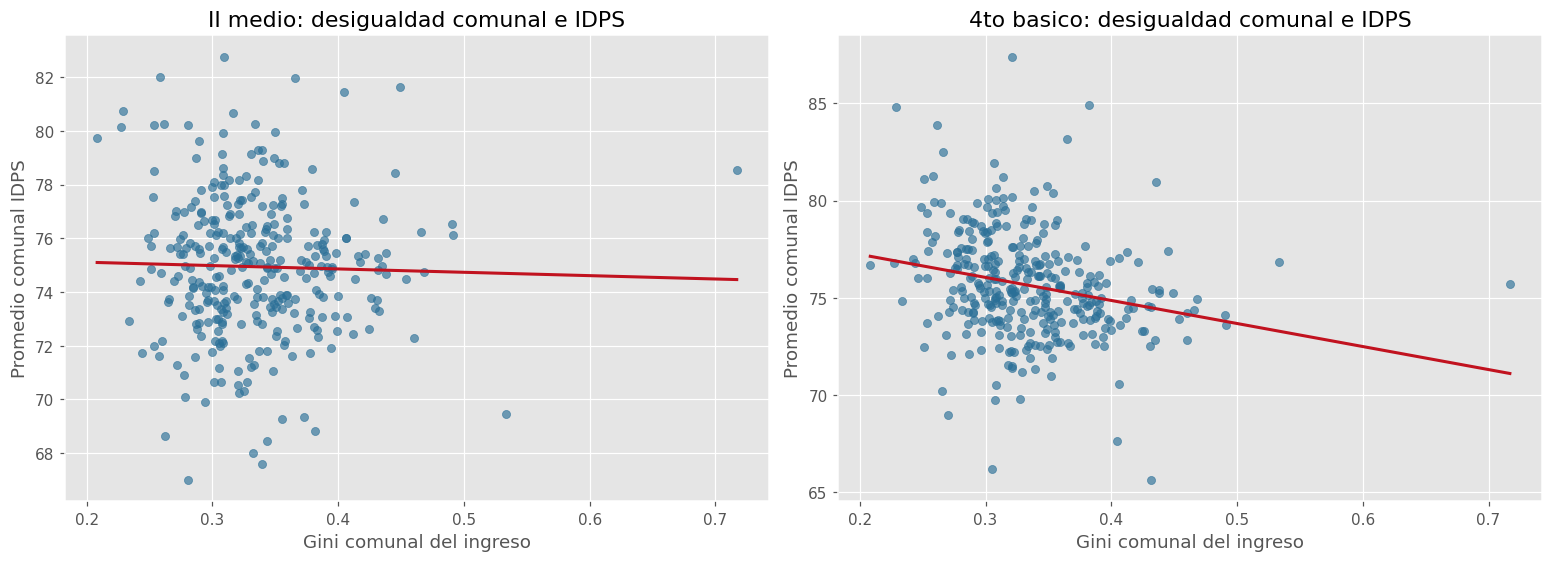

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, y_col, titulo in [
    (axes[0], 'promedio_idps_2m', 'II medio: desigualdad comunal e IDPS'),
    (axes[1], 'promedio_idps_4b', '4to basico: desigualdad comunal e IDPS')
]:
    temp = comunas_analisis.dropna(subset=['gini_ingreso', y_col])
    x = temp['gini_ingreso'].to_numpy(dtype=float)
    y = temp[y_col].to_numpy(dtype=float)

    ax.scatter(x, y, alpha=0.65, s=28, color='#2a6f97')
    if len(temp) >= 2:
        coef = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = coef[0] * x_line + coef[1]
        ax.plot(x_line, y_line, color='#c1121f', linewidth=2)

    ax.set_title(titulo)
    ax.set_xlabel('Gini comunal del ingreso')
    ax.set_ylabel('Promedio comunal IDPS')

plt.show()

### Hallazgos preliminares de la semana 2

A partir del analisis exploratorio inicial, aparecen cuatro patrones que conviene dejar documentados:

- El cruce comunal entre CASEN e IDPS **si se puede construir** de forma limpia usando el codigo de comuna.
- La relacion entre desigualdad de ingresos comunal e IDPS **no aparece fuerte ni lineal** en II medio, y en 4to basico se observa una asociacion negativa algo mas clara pero todavia moderada.
- La pobreza comunal tampoco muestra un patron simple: en estas bases el promedio IDPS no cae automaticamente cuando sube la pobreza, lo que sugiere presencia de variables de contexto relevantes.
- La **ruralidad** parece importante: en ambos cortes los establecimientos rurales muestran, en promedio, puntajes IDPS mayores que los urbanos, por lo que puede actuar como factor de confusion.

En otras palabras, el analisis preliminar no permite afirmar todavia una relacion directa y simple entre desigualdad socioeconomica y resultado escolar. Lo que si muestra es que la pregunta es interesante, pero exige afinar la definicion de resultado educativo y controlar mejor el contexto territorial.

## Semana 3. Profundizacion del contexto

### Contexto de las bases utilizadas

En esta etapa ya no basta con mostrar tablas: tambien hay que justificar por que estas bases sirven para la pregunta y cuales son sus limites.

- **CASEN 2022** aporta el contexto socioeconomico de las personas y hogares: ingreso, pobreza, escolaridad y condiciones materiales.
- La base territorial de CASEN permite ubicar cada registro en una **comuna**, que es la llave del cruce.
- **IDPS 2022** aporta resultados educacionales no academicos: autoestima academica, convivencia escolar, habitos de vida saludable y participacion/formacion ciudadana.
- La glosa oficial de IDPS permite interpretar correctamente indicadores, dimensiones, dependencia y grupo socioeconomico escolar.

### Alcance real del avance

Con estas bases, la formulacion mas precisa para esta etapa es:

> **Existe una asociacion entre la desigualdad socioeconomica comunal y los puntajes promedio comunales de IDPS en 4to basico y II medio?**

Eso no reemplaza del todo la pregunta original sobre rendimiento academico, pero si permite construir un avance metodologicamente consistente con lo disponible.

In [12]:
glosario = pd.DataFrame([
    {
        'termino': 'IDPS',
        'tipo': 'Concepto',
        'descripcion': 'Indicadores de Desarrollo Personal y Social reportados por establecimiento.'
    },
    {
        'termino': 'cod_com_rbd / cod_comuna',
        'tipo': 'Llave de cruce',
        'descripcion': 'Codigo de comuna usado para unir resultados escolares con indicadores territoriales de CASEN.'
    },
    {
        'termino': 'ypchtotcor',
        'tipo': 'Variable CASEN',
        'descripcion': 'Ingreso per capita corregido del hogar; se usa para resumir nivel de ingreso comunal.'
    },
    {
        'termino': 'gini_ingreso',
        'tipo': 'Indicador construido',
        'descripcion': 'Medida de desigualdad del ingreso dentro de cada comuna. Mientras mas alto, mayor desigualdad.'
    },
    {
        'termino': 'pobreza_total_pct',
        'tipo': 'Indicador construido',
        'descripcion': 'Porcentaje comunal estimado de personas en pobreza por ingresos (categorias 1 o 2 de CASEN).'
    },
    {
        'termino': 'pobreza_multi_pct',
        'tipo': 'Indicador construido',
        'descripcion': 'Porcentaje comunal estimado de pobreza multidimensional.'
    },
    {
        'termino': 'cod_depe2',
        'tipo': 'Variable IDPS',
        'descripcion': 'Dependencia administrativa del establecimiento: municipal, particular subvencionado, particular pagado o SLEP.'
    },
    {
        'termino': 'cod_grupo',
        'tipo': 'Variable IDPS',
        'descripcion': 'Grupo socioeconomico del establecimiento escolar, desde bajo hasta alto.'
    },
    {
        'termino': 'cod_rural_rbd',
        'tipo': 'Variable IDPS',
        'descripcion': 'Clasifica el establecimiento como urbano o rural.'
    },
    {
        'termino': 'AM',
        'tipo': 'Indicador IDPS',
        'descripcion': 'Autoestima academica y motivacion escolar.'
    },
    {
        'termino': 'CC',
        'tipo': 'Indicador IDPS',
        'descripcion': 'Clima de convivencia escolar.'
    },
    {
        'termino': 'HV',
        'tipo': 'Indicador IDPS',
        'descripcion': 'Habitos de vida saludable.'
    },
    {
        'termino': 'PF',
        'tipo': 'Indicador IDPS',
        'descripcion': 'Participacion y formacion ciudadana.'
    }
])

glosario

,termino,tipo,descripcion
0,IDPS,Concepto,Indicadores de Desarrollo Personal y Social re...
1,cod_com_rbd / cod_comuna,Llave de cruce,Codigo de comuna usado para unir resultados es...
2,ypchtotcor,Variable CASEN,Ingreso per capita corregido del hogar; se usa...
3,gini_ingreso,Indicador construido,Medida de desigualdad del ingreso dentro de ca...
4,pobreza_total_pct,Indicador construido,Porcentaje comunal estimado de personas en pob...
5,pobreza_multi_pct,Indicador construido,Porcentaje comunal estimado de pobreza multidi...
6,cod_depe2,Variable IDPS,Dependencia administrativa del establecimiento...
7,cod_grupo,Variable IDPS,Grupo socioeconomico del establecimiento escol...
8,cod_rural_rbd,Variable IDPS,Clasifica el establecimiento como urbano o rural.
9,AM,Indicador IDPS,Autoestima academica y motivacion escolar.


In [13]:
contexto_dimensiones = pd.DataFrame([
    {'codigo': k, 'dimension_idps': v} for k, v in MAP_DIMENSION.items()
]).sort_values('codigo')

contexto_indicadores = pd.DataFrame([
    {'codigo': k, 'indicador_idps': v} for k, v in MAP_INDICADOR.items()
]).sort_values('codigo')

print('Indicadores IDPS considerados en el analisis')
display(contexto_indicadores)
print()
print('Dimensiones IDPS identificadas desde la glosa oficial')
display(contexto_dimensiones)

Indicadores IDPS considerados en el analisis


,codigo,indicador_idps
0,AM,Autoestima academica y motivacion escolar
1,CC,Clima de convivencia escolar
2,HV,Habitos de vida saludable
3,PF,Participacion y formacion ciudadana



Dimensiones IDPS identificadas desde la glosa oficial


,codigo,dimension_idps
0,AA,Autopercepcion y autovaloracion academica
1,AC,Habitos de autocuidado
2,AO,Ambiente organizado
3,AR,Ambiente de respeto
4,AS,Ambiente seguro
5,HA,Habitos alimentarios
6,ME,Motivacion escolar
7,PA,Participacion
8,SP,Sentido de pertenencia
9,VA,Habitos de vida activa


### Limitaciones detectadas en la profundizacion del contexto

- La variable de resultado disponible es **IDPS**, no rendimiento academico estricto.
- El cruce actual trabaja a **nivel comunal**, por lo que la interpretacion es ecologica y no individual.
- La relacion observada puede estar afectada por **ruralidad**, dependencia escolar, tamano comunal y composicion interna de cada territorio.
- Para una etapa posterior convendria evaluar modelos separados para 4to basico y II medio, e idealmente incorporar una medida academica adicional.

### Preguntas de investigacion preliminares para la siguiente fase

1. La desigualdad de ingresos comunal medida con Gini se asocia de forma distinta con IDPS en 4to basico y en II medio?
2. La pobreza multidimensional explica mejor las diferencias comunales en IDPS que la pobreza por ingresos?
3. La ruralidad y la dependencia administrativa modifican la relacion entre contexto socioeconomico y resultados escolares?
4. Conviene reformular la pregunta final hacia bienestar/desarrollo escolar o complementar la base con SIMCE para hablar de rendimiento academico en sentido estricto?

Con esto queda cubierto el avance solicitado hasta la **semana 3**, incluyendo exploracion inicial, profundizacion del contexto y un glosario de trabajo.